<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


Top 15 Developer Types:
DevType
Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Other (please specify):                           2458
Developer, mobile                                 2021
Developer, embedded applications or devices       1623
Engineering manager                               1275
Academic researcher                               1238
Data engineer                                     1118
Data scientist or machine learning specialist     1024
DevOps specialist                                 1019
Research & Development role                        943
Senior Executive (C-Suite, VP, etc.)               837
Name: count, dtype: int64

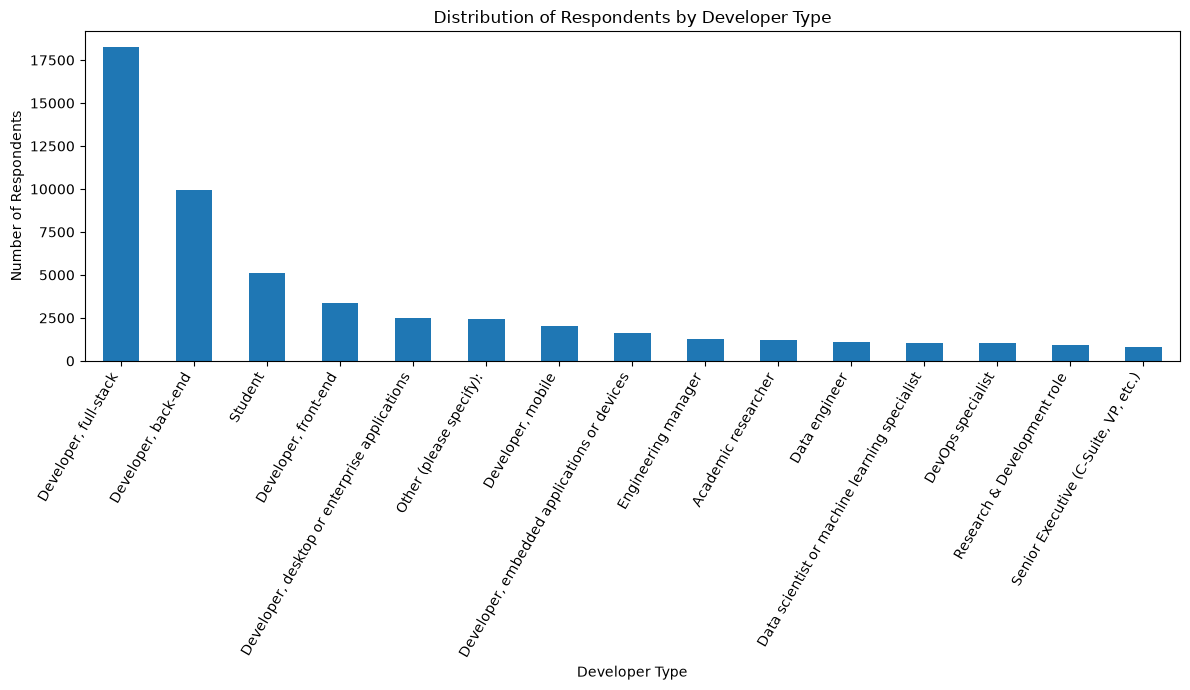

In [3]:
##Write your code here
## Write your code here

# Count respondents by developer type
dev_type_counts = df["DevType"].value_counts().head(15)

print("Top 15 Developer Types:")
print(dev_type_counts)

# Create bar chart
plt.figure(figsize=(12, 7))

dev_type_counts.plot(kind="bar")

plt.title("Distribution of Respondents by Developer Type")
plt.xlabel("Developer Type")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [4]:
##Write your code here
## Write your code here

# Remove missing compensation values for statistical calculations
compensation = df["ConvertedCompYearly"].dropna()

# Calculate statistics
mean_compensation = compensation.mean()
median_compensation = compensation.median()
std_compensation = compensation.std()

print("Mean compensation:", mean_compensation)
print("Median compensation:", median_compensation)
print("Standard deviation:", std_compensation)

# Define the high compensation threshold
threshold = mean_compensation + (3 * std_compensation)

print("\nHigh compensation threshold:", threshold)

# Identify high compensation outliers
high_compensation = df[
    df["ConvertedCompYearly"] > threshold
]

print("\nNumber of high compensation outliers:",
      len(high_compensation))

print("\nHigh compensation values:")
print(
    high_compensation[
        ["Country", "ConvertedCompYearly"]
    ].sort_values(
        "ConvertedCompYearly",
        ascending=False
    ).head(20)
)

Mean compensation: 86155.28726264134
Median compensation: 65000.0
Standard deviation: 186756.97308629754

High compensation threshold: 646426.206521534

Number of high compensation outliers: 89

High compensation values:
                        Country  ConvertedCompYearly
15837                  Ethiopia           16256603.0
12723              South Africa           13818022.0
28379                    Taiwan            9000000.0
17593                    Brazil            6340564.0
17672                   Ukraine            4936778.0
19267                     India            3367716.0
23694                  Pakistan            2584118.0
33720                    Brazil            2237846.0
34523                  Pakistan            2153432.0
13763                 Australia            2048046.0
22842                    Brazil            2014062.0
2187                      Gabon            2000000.0
27902                  Pakistan            2000000.0
36329  United States of America      

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1: 32712.0
Q3: 107971.5
IQR: 75259.5
Lower bound: -80177.25
Upper bound: 220860.75

Number of outliers: 978

First 10 outliers:
            Country  ConvertedCompYearly
15837      Ethiopia           16256603.0
12723  South Africa           13818022.0
28379        Taiwan            9000000.0
17593        Brazil            6340564.0
17672       Ukraine            4936778.0
19267         India            3367716.0
23694      Pakistan            2584118.0
33720        Brazil            2237846.0
34523      Pakistan            2153432.0
13763     Australia            2048046.0

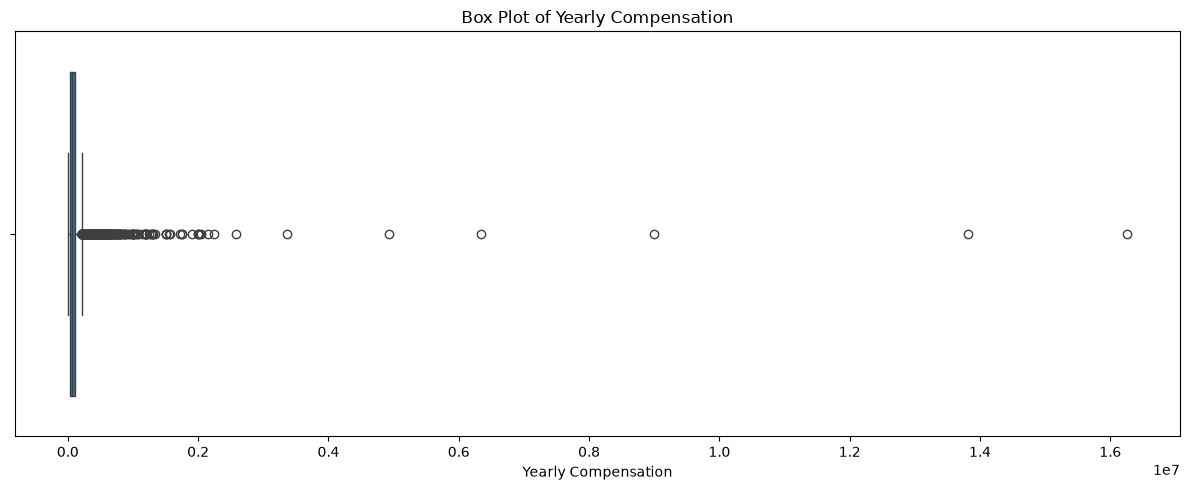

In [5]:
##Write your code here
## Write your code here

# Remove missing values
compensation = df["ConvertedCompYearly"].dropna()

# Calculate Q1 and Q3
Q1 = compensation.quantile(0.25)
Q3 = compensation.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate outlier bounds
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Identify outliers
outliers = df[
    (df["ConvertedCompYearly"] < lower_bound) |
    (df["ConvertedCompYearly"] > upper_bound)
]

print("\nNumber of outliers:", len(outliers))

# Display some outliers
print("\nFirst 10 outliers:")
print(
    outliers[
        ["Country", "ConvertedCompYearly"]
    ].sort_values(
        "ConvertedCompYearly",
        ascending=False
    ).head(10)
)

# Create box plot
plt.figure(figsize=(12, 5))

sns.boxplot(
    x=df["ConvertedCompYearly"]
)

plt.title("Box Plot of Yearly Compensation")
plt.xlabel("Yearly Compensation")
plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [6]:
## Write your code here

# Create a new DataFrame without compensation outliers
df_no_outliers = df[
    (df["ConvertedCompYearly"].isna()) |
    (
        (df["ConvertedCompYearly"] >= lower_bound) &
        (df["ConvertedCompYearly"] <= upper_bound)
    )
].copy()

# Compare dataset sizes
print("Original dataset shape:", df.shape)
print("Dataset shape after removing outliers:",
      df_no_outliers.shape)

# Calculate number of removed rows
removed_rows = len(df) - len(df_no_outliers)

print("Number of rows removed:", removed_rows)

# Verify that no compensation outliers remain
remaining_outliers = df_no_outliers[
    (df_no_outliers["ConvertedCompYearly"] < lower_bound) |
    (df_no_outliers["ConvertedCompYearly"] > upper_bound)
]

print("Remaining outliers:", len(remaining_outliers))

Original dataset shape: (65437, 114)
Dataset shape after removing outliers: (64459, 114)
Number of rows removed: 978
Remaining outliers: 0

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


Numerical columns:
['ResponseId', 'CompTotal', 'WorkExp', 'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat', 'Age_numeric', 'YearsCodePro_numeric']

Correlations with Age:
Age_numeric             1.000000
WorkExp                 0.851248
YearsCodePro_numeric    0.834615
ConvertedCompYearly     0.367714
JobSat                  0.068299
CompTotal              -0.002799
JobSatPoints_1         -0.029405
ResponseId             -0.031545
JobSatPoints_8         -0.045845
JobSatPoints_6         -0.049758
JobSatPoints_4         -0.075065
JobSatPoints_9         -0.080287
JobSatPoints_7         -0.080309
JobSatPoints_5         -0.100472
JobSatPoints_11        -0.106081
JobSatPoints_10        -0.112117
Name: Age_numeric, dtype: float64

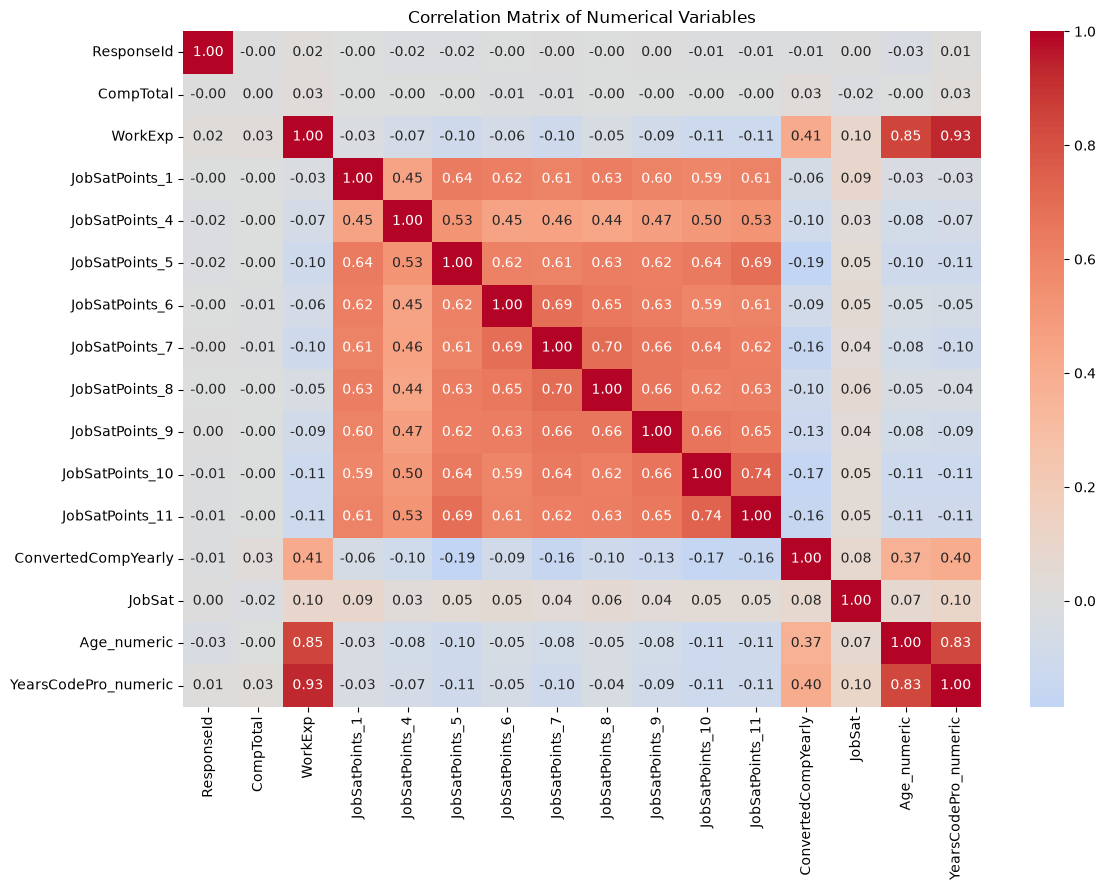

In [7]:
## Write your code here

# Map Age categories to approximate numeric values
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

# Create numeric Age column
df_no_outliers["Age_numeric"] = df_no_outliers["Age"].map(age_mapping)

# Convert YearsCodePro to numeric
years_code_pro = df_no_outliers["YearsCodePro"].replace({
    "Less than 1 year": "0",
    "More than 50 years": "51"
})

df_no_outliers["YearsCodePro_numeric"] = pd.to_numeric(
    years_code_pro,
    errors="coerce"
)

# Make sure compensation is numeric
df_no_outliers["ConvertedCompYearly"] = pd.to_numeric(
    df_no_outliers["ConvertedCompYearly"],
    errors="coerce"
)

# Select numerical columns
numeric_columns = df_no_outliers.select_dtypes(
    include="number"
).columns

print("Numerical columns:")
print(numeric_columns.tolist())

# Calculate correlations with Age
age_correlations = (
    df_no_outliers[numeric_columns]
    .corr()["Age_numeric"]
    .sort_values(ascending=False)
)

print("\nCorrelations with Age:")
print(age_correlations)

# Create correlation matrix
correlation_matrix = df_no_outliers[
    numeric_columns
].corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
